# BrushCue Example: Rotate & Straighten

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/rotate_straighten.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/rotate-straighten

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


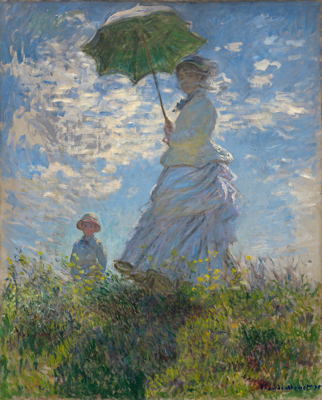

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
bounds = input_image.bounds()
cx = bounds.min_x() + (bounds.width() / 2.0)
cy = bounds.min_y() + (bounds.height() / 2.0)
angle = 0.0
angle_rad = angle * 0.017453292
rotated = input_image.transform(
    bc.Transform2.identity()
    .translation(bc.Vector2f.from_components((0.0 - cx), (0.0 - cy)))
    .rotate(angle_rad)
    .translation(bc.Vector2f.from_components(cx, cy))
)
rb = rotated.bounds()
rcx = rb.min_x() + (rb.width() / 2.0)
rcy = rb.min_y() + (rb.height() / 2.0)
backdrop_color = bc.ProfiledColor.from_srgb_hex("#FFFFFF")
backdrop = bc.Composition.painter(
    bc.Painter.new().add_rectangle_with_render_style(
        bc.Point2f.from_components(rcx, rcy),
        bc.Vector2f.from_components(rb.width(), rb.height()),
        0.0,
        bc.RenderStyle.fill_only(bc.Fill.solid(backdrop_color)),
        bc.Transform2.identity().to_list(),
    )
)
graph = rotated.blend_alpha(backdrop, bc.Transform2.identity()).crop(rb)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
